# Assignment 6: Reduction of dimensionality and recognition

## Exercise 1: Direct PCA method

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import a6_utils as a6
import os

1a) solved in my notes

1b) and c)

In [33]:
def pca(points):
    mean = points.mean(axis=0)

    points2 = points - mean
    n = points2.shape[0]
    c = (points2.T @ points2) / (n - 1)

    U, S, Vt = np.linalg.svd(c, full_matrices=False)

    evecs = U
    evals = S
    # print("eigenvalues:", evals)
    # print("eigenvectors:", evecs)

    return mean, points2, c, evals, evecs


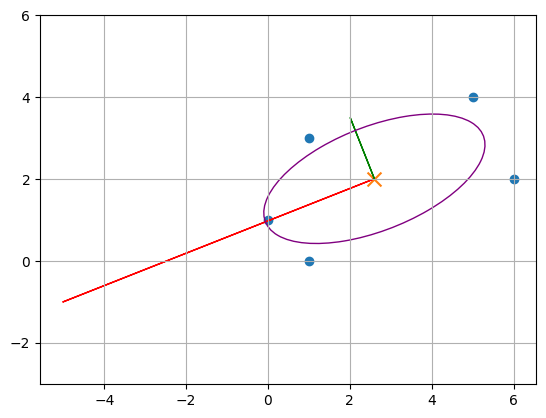

In [34]:
points = np.loadtxt("data/points.txt")

mean, points2, c, evals, evecs = pca(points)
pc1 = evecs[:,0]
pc2 = evecs[:,1]
# print(mean)
if pc2[1] < 0:
    pc2 *= -1

s1 = evals[0]
s2 = evals[1]

plt.figure()
plt.scatter(points[:,0], points[:,1])
plt.scatter(mean[0], mean[1], marker="x", s=100)
plt.axis("equal")
plt.grid(True)

plt.arrow(mean[0], mean[1], pc1[0]*s1, pc1[1]*s1, color="r", length_includes_head=True)
plt.arrow(mean[0], mean[1], pc2[0]*s2, pc2[1]*s2, color="g", length_includes_head=True)

a6.drawEllipse(mean, c)

plt.axis("equal")
plt.grid(True)
plt.show()

**Question: What do you notice about the relationship between the eigenvectors and the data? What happens to the eigenvectors if you change the data or add more points?**
The eigenvectors align with the main directions of how the data is spread. The first eigenvector points in the direction where the data has the largest variance, meaning where the points are most stretched out, while the second eigenvector is perpendicular to it and corresponds to smaller variance.
If you change the data or add more points, the covariance matrix changes as well, so the eigenvectors can rotate and change their direction. When new points extend the data in a certain direction, the first eigenvector will move toward that new dominant direction. This shows that eigenvectors are not fixed.

1d)

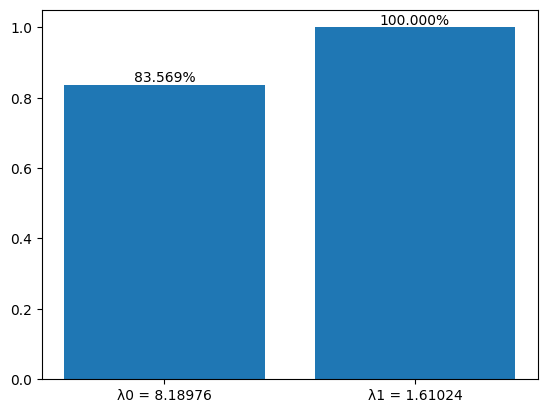

In [6]:
relative_variance = np.cumsum(evals) / np.sum(evals)

labels = [f"λ{i} = {lam:.5f}" for i, lam in enumerate(evals)]

plt.figure()
bars = plt.bar(labels, relative_variance)

for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{relative_variance[i]*100:.3f}%",
        ha="center",
        va="bottom"
    )
plt.show()

1e)

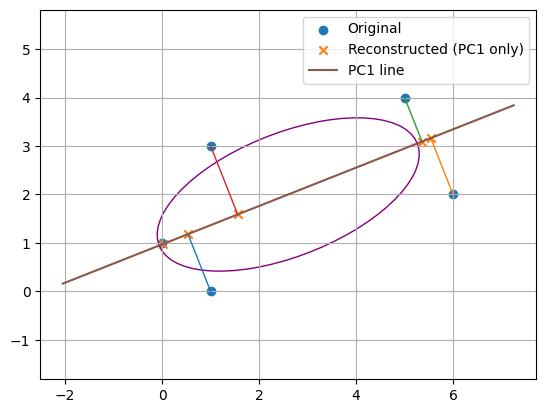

In [35]:
U = evecs
Z = points2 @ U #transformation into PCA space
Z_reduced = Z.copy()
Z_reduced[:, 1] = 0.0
recon_points = Z_reduced @ U.T + mean #reconstructing back to the original space

plt.figure()
plt.scatter(points[:,0], points[:,1], label="Original")
plt.scatter(recon_points[:,0], recon_points[:,1], marker="x", label="Reconstructed (PC1 only)")

for i in range(points.shape[0]):
    plt.plot([points[i,0], recon_points[i,0]], [points[i,1], recon_points[i,1]], linewidth=1)

pc1 = U[:,0]
t = np.linspace(-5, 5, 100)
line = mean + t[:,None] * pc1
plt.plot(line[:,0], line[:,1], label="PC1 line")

a6.drawEllipse(mean, c)

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

**Question: What happens to the reconstructed points? Where is the data projected
to?**
Reconstructed points lie on the first principal component line.

1f)

Original distances:  [7.81024968 4.         2.23606798 5.83095189 7.81024968]
Closest original point:  [5. 4.] distance:  2.23606797749979
Closest after projection: [6. 2.] distance: 1.4709528771783675


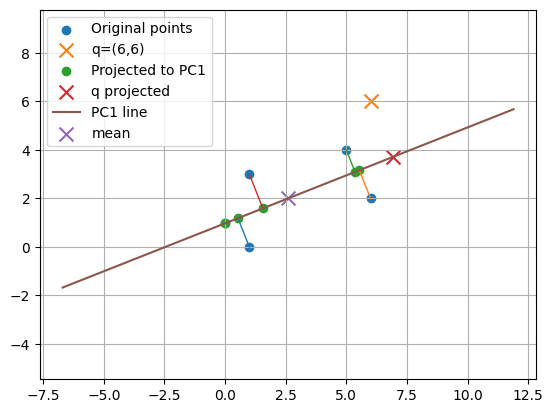

In [8]:
q = np.array([6.0, 6.0])

d = np.linalg.norm(points - q, axis=1)
i0 = np.argmin(d)
print("Original distances: ", d)
print("Closest original point: ", points[i0], "distance: ", d[i0])

mean, points2, c, evals, evecs = pca(points)
pc1 = evecs[:,0]

a_points = (points - mean) @ pc1
a_q = (q - mean) @ pc1
points_rec = mean + a_points[:, None] * pc1
q_rec = mean + a_q * pc1

d_rec = np.linalg.norm(points_rec - q_rec, axis=1)
i1 = np.argmin(d_rec)
print("Closest after projection:", points[i1], "distance:", d_rec[i1])

plt.figure()
plt.scatter(points[:,0], points[:,1], label="Original points")
plt.scatter(q[0], q[1], marker="x", s=100, label="q=(6,6)")

plt.scatter(points_rec[:,0], points_rec[:,1], label="Projected to PC1")
plt.scatter(q_rec[0], q_rec[1], marker="x", s=100, label="q projected")

for i in range(points.shape[0]):
    plt.plot([points[i,0], points_rec[i,0]],
             [points[i,1], points_rec[i,1]], linewidth=1)

t = np.linspace(-10, 10, 200)
line = mean + t[:, None] * pc1
plt.plot(line[:,0], line[:,1], label="PC1 line")

plt.scatter(mean[0], mean[1], marker="x", s=100, label="mean")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

In [36]:
points50 = np.loadtxt("data/points_50D.txt")
mu = points50.mean(axis=0)
points50_2 = points50 - mu
U, S, Vt = np.linalg.svd(points50_2, full_matrices=False)

n = points50.shape[0]
evals = (S**2) / (n-1)
ratios = evals / evals.sum()
cum = np.cumsum(ratios)

k = np.searchsorted(cum, 0.8) + 1
can_zero = points50.shape[1] - k

print("k (components to keep):", k)
print("Can set to zero:", can_zero)
print("Cum variance at k:", cum[k-1])

k (components to keep): 19
Can set to zero: 31
Cum variance at k: 0.8067541951571175


## Exercise 2: The dual PCA method

2a)

In [10]:
def dualPCA(X):
    mean = np.array([np.mean(X, axis=1)]).T
    Xd = X - mean
    n = X.shape[1]
    c = (Xd.T @ Xd) / (n - 1)
    U, S, Vt = np.linalg.svd(c)
    U = Xd @ U @ np.diag(np.sqrt(1 / ((S + 1e-15) * (n - 1))))

    return mean, c, U, S

In [11]:
X = np.loadtxt("data/points.txt")
Xt = X.T
mean, points2, c, evals, evecs = pca(X)
mean, C, U, S = dualPCA(Xt)
print("This is the PCA U:")
print(evecs)
print("This is the dual PCA U:")
np.set_printoptions(formatter={'float': '{:0.8f}'.format})
print(U)

This is the PCA U:
[[-0.92992935  0.36773822]
 [-0.36773822 -0.92992935]]
This is the dual PCA U:
[[0.92992935 -0.36773822 0.00000001 0.00000000 0.00000000]
 [0.36773822 0.92992935 0.00000000 0.00000000 0.00000000]]


2b)

In [12]:
X = np.loadtxt("data/points.txt")

mean_d, C_d, U_d, S_d = dualPCA(X)
U = U_d[:, :2]
Xc = X - mean_d

Z = U.T @ Xc
X_rec = U @ Z + mean_d

print(np.linalg.norm(X - X_rec))
print("Matrix X and Xq are the same: ", np.all(np.abs(X - X_rec) < 1e-12))

2.5703521317566537e-15
Matrix X and Xq are the same:  True


## Exercise 3: Image decomposition examples

3a)

In [13]:
def preparation(path="data/faces/1"):
    X = []
    for imgpath in os.listdir(path):
        img = cv2.imread(f"{path}/{imgpath}", cv2.IMREAD_GRAYSCALE)
        img = img.reshape(-1)
        X.append(img)
    return np.array(X).T

In [14]:
X = preparation()
print(X[:10, :10])

[[ 72  58  78  39  76   2  60  57  74  83]
 [ 72  59  77  42  74   1  61  57  77  84]
 [ 73  61  79  43  76   2  63  58  80  87]
 [ 76  61  81  44  79   2  63  60  80  89]
 [ 78  62  84  45  80   2  65  62  82  90]
 [ 81  63  87  44  83   2  67  64  85  93]
 [ 86  68  91  45  85   3  68  64  85  95]
 [ 93  75  98  51  93   3  77  72  93 104]
 [102  82 107  56 101   3  85  79 101 112]
 [109  87 114  62 109   3  93  86 106 120]]


3b)

In [15]:
def dualPCA_images(X, eps=1e-15):
    X = np.asarray(X, dtype=np.float64)
    mean = np.mean(X, axis=1, keepdims=True)
    Xc = X - mean
    N = X.shape[1]

    C_dual = (Xc.T @ Xc) / (N - 1)
    Uc, S, Vt = np.linalg.svd(C_dual)

    scale = np.sqrt(1.0 / ((S + eps) * (N - 1)))
    Ue = Xc @ (Uc * scale[np.newaxis, :])

    return mean, Ue, S

In [16]:
def show_eigenfaces(Ue, h, w, k=5):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 3))
    for i in range(k):
        plt.subplot(1, k, i+1)
        plt.imshow(Ue[:, i].reshape(h, w), cmap="gray")
        plt.title(f"PC{i+1}")
        plt.axis("off")
    plt.show()
    return

In [17]:
def reconstruct_one(img, mean, Ue):
    img = np.asarray(img, dtype=np.float64).reshape(-1, 1)
    y = Ue.T @ (img - mean)
    x_rec = Ue @ y + mean
    return img, y, x_rec

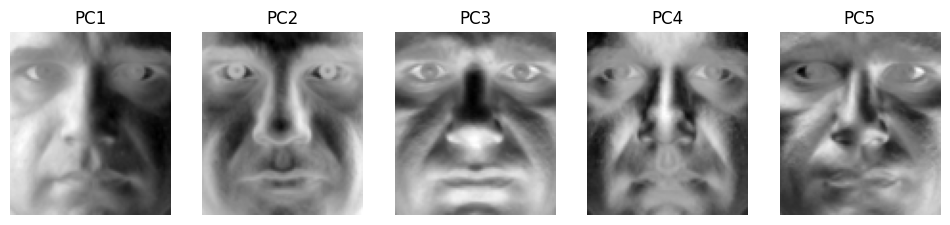

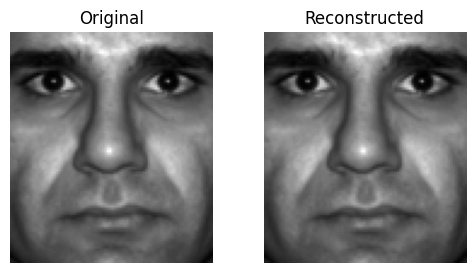

In [38]:
X = preparation("data/faces/1")
mean, Ue, S = dualPCA_images(X)

show_eigenfaces(Ue, h=96, w=84, k=5)
img = X[:,0]
x1, y1, x1_rec = reconstruct_one(img, mean, Ue)
h = 96
w = 84

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1); plt.imshow(np.asarray(x1).reshape(h, w), cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(x1_rec.reshape(h, w), cmap="gray")
plt.title("Reconstructed")
plt.axis("off")
plt.show()

**What do the resulting images represent (both numerically and in the context of faces)?**
They represent illumination changes, face shape, eye and nose structure, and other dominant features. Each original face image can be approximated as a linear combination of these eigenfaces. Numerically, each eigenvector corresponds to a basis vector of the PCA subspace, describing how pixel intensities change together across the dataset.
**Project the first image from the series to the PCA space and then back again. Is the result the same?**
If all principal components are used, the reconstructed image becomes (up to numerical precision) identical to the original image.

3c)

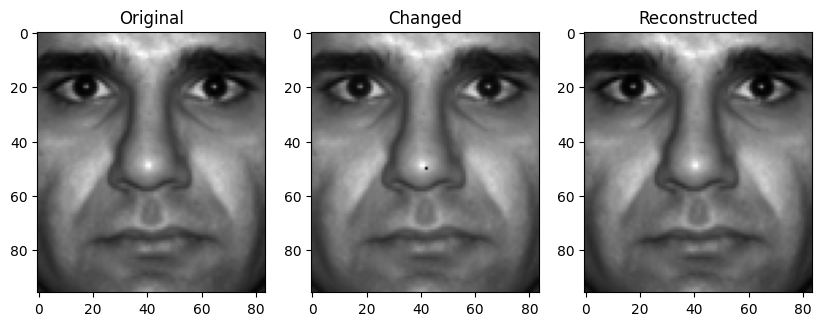

In [19]:
X = preparation("data/faces/1")
img = X[:, 0]
img_changed = img.copy()
row = 50
col = 42
idx = row * 84 + col
img_changed[idx] = 0
x1, y1, x1_rec = reconstruct_one(img, mean, Ue)
h = 96
w = 84

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1); plt.imshow(np.asarray(x1).reshape(h, w), cmap="gray")
plt.title("Original")
plt.subplot(1, 3, 2)
plt.imshow(img_changed.reshape(h, w), cmap="gray")
plt.title("Changed")
plt.subplot(1, 3, 3)
plt.imshow(x1_rec.reshape(h, w), cmap="gray")
plt.title("Reconstructed")
plt.show()

In [20]:
def reconstruct_one_pca_changed(img, mean, Ue, comp=0):
    img = np.asarray(img, dtype=np.float64).reshape(-1, 1)
    y = Ue.T @ (img - mean)

    y_changed = y.copy()
    y_changed[comp, 0] = 0.0

    x_rec = Ue @ y_changed + mean
    return img, y, y_changed, x_rec

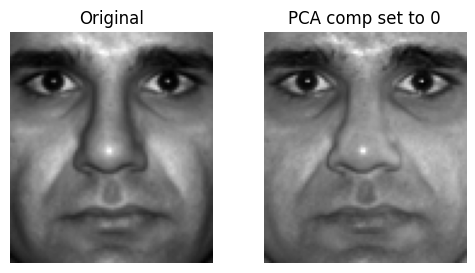

8064


In [21]:
x1 = X[:, 0]
img, y, y_ch, x_rec = reconstruct_one_pca_changed(x1, mean, Ue, comp=1)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(img.reshape(h,w), cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(x_rec.reshape(h,w), cmap="gray")
plt.title("PCA comp set to 0")
plt.axis("off")
plt.show()

changed_pixels = np.sum(np.abs(x_rec - img) > 1e-12)
print(changed_pixels)

3d)

In [22]:
def reconstruct_with_k(img, mean, Ue, k):
    img = np.asarray(img, dtype=np.float64).reshape(-1, 1)

    y = Ue.T @ (img - mean)
    yk = y.copy()
    yk[k:, 0] = 0.0
    x_rec = Ue @ yk + mean

    return x_rec

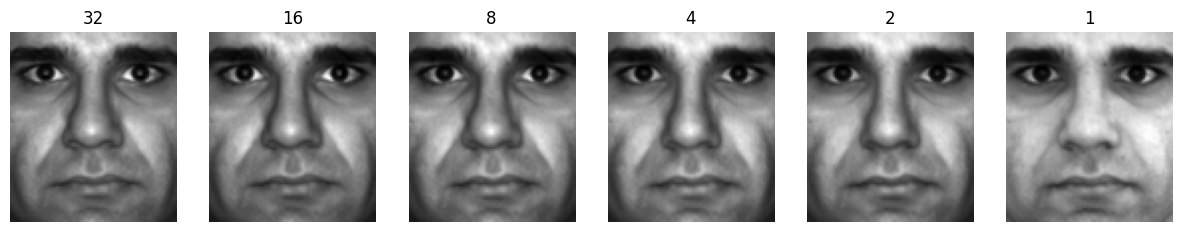

In [23]:
h, w = 96, 84
ks = [32, 16, 8, 4, 2, 1]

img = np.asarray(X[:, 0], dtype=np.float64).reshape(-1, 1)
y = Ue.T @ (img - mean)

plt.figure(figsize=(15, 5))

for i, k in enumerate(ks):
    yk = y.copy()
    yk[k:, 0] = 0.0

    x_rec = Ue @ yk + mean

    plt.subplot(1, len(ks), i+1)
    plt.imshow(x_rec.reshape(h, w), cmap="gray")
    plt.title(str(k))
    plt.axis("off")

plt.show()

3f)

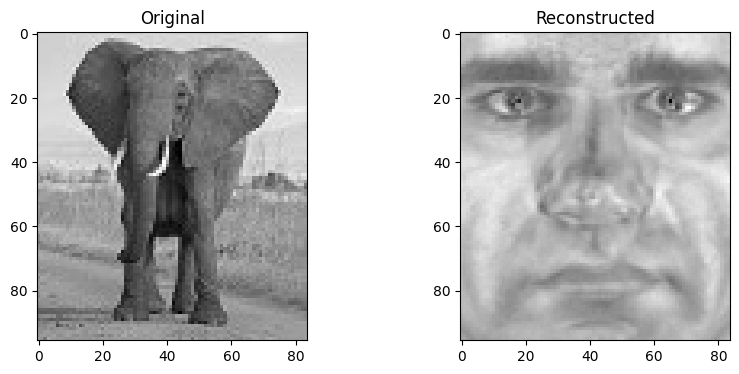

In [24]:
X = preparation("data/faces/1")
elephant = cv2.imread("data/elephant.jpg", cv2.IMREAD_GRAYSCALE).reshape(-1, 1)

mean, _, U, _ = dualPCA(X)
elephant1 = U.T @ (elephant - mean)
elephant2 = U @ elephant1 + mean

_, plot = plt.subplots(1,2,figsize=(10,4))
plot[0].imshow(elephant.reshape(h,w), cmap="gray")
plot[0].set_title("Original")
plot[1].imshow(elephant2.reshape(h,w), cmap="gray")
plot[1].set_title("Reconstructed")
plt.show()

Projecting a non-face image (elephant) into a PCA subspace learned from faces and reconstructing it produces a face-like image. This happens because the PCA subspace can only represent patterns present in the training data (faces). Components specific to the elephant are not represented and are projected onto the closest combination of eigenfaces, making a distorted face.